In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
# from TimeEmbeddingModel import AEric2, h5set, test_function, save_everything, load_everything
import custom.tools as tl
import custom.models as mod
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
trial_dir = "../multi_feat_model_stuff/trials/"
load_path = f"{trial_dir}item2_20_epoch163.pt"
t_set,v_set,t_loader,v_loader, model, optimizer, scaler, clip, losses, epoch, scheduler = load_everything(load_path, torch.optim.RMSprop, device)

a = torch.load(load_path, map_location=device)
losses = a['losses']

In [6]:
## GIO
# trial_dir = "../multi_feat_model_stuff/trials/"
# load_path = f"{trial_dir}item2_20_epoch163.pt"
# t_set,v_set,t_loader,v_loader, model, optimizer, scaler, clip, losses, epoch, scheduler = load_everything(load_path, torch.optim.RMSprop, device)
with open('/mnt/eph/uni_feat_model_stuff/trial_20/losses_255.pickle', 'rb') as fin: losses = pickle.load(fin)
optuna_save = torch.load('/mnt/eph/data/optuna/artifacts/ba4a7fec-42c2-4b9f-a9cb-bc4f448671b1', weights_only=False)
dicts_save = torch.load('/mnt/eph/uni_feat_model_stuff/trial_20/mod_opt_scal_240.pt')
print(win_len := optuna_save['train_set_params']['win_len'], win_stride := optuna_save['train_set_params']['win_stride'])

100 60


last loss: 0.005523008869049397
smallest train loss: 0.005660272280854161
Num_epochs: 255


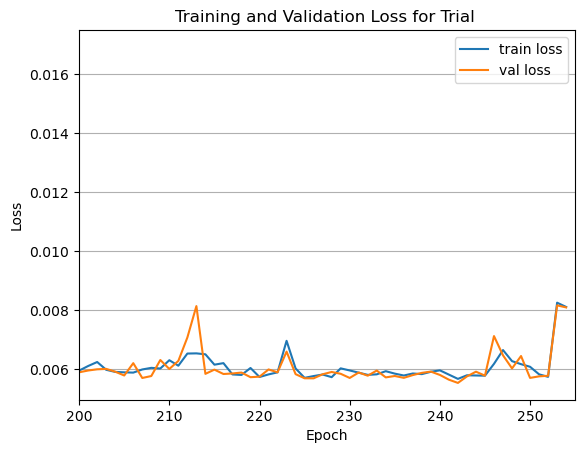

In [17]:
print('last loss:',smallest := min(losses['val']))
print('smallest train loss:', min(losses['train']))
train = losses['train']
val = losses['val']
lenght = len(train)
print("Num_epochs:", lenght)
plt.plot(train, label='train loss')
plt.plot(val, label='val loss')
#plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training and Validation Loss for Trial ')
#plt.yscale('log')
# plt.yticks(list(plt.yticks()[0])+[smallest])
plt.grid(which='both',axis='y')
# plt.ylim(0.0125, 0.0135)
# plt.ylim(0.0055, 0.006)
plt.xlim(200, 255)
plt.legend()
plt.show()

In [45]:
## Gio
main_dir = "/mnt/eph/multi_feat_model_stuff/"
h5file= "L1_70_12_6_6.h5"
#h5file = "real_event_just_strain.h5"
dir_path = f"{main_dir}subsets"
h5_path = f"/mnt/eph/data/{h5file}"


batch_size = 1

# win_len = t_set.win_len
# win_stride = t_set.win_stride
num_workers = 10 #os.cpu_count() if os.cpu_count() is not None else 0
persistent_workers = False
#test = h5set(h5_path,win_len=win_len, win_stride=win_stride, name='C') #10k rows
test = tl.h5set(h5_path,win_len=win_len, win_stride=win_stride, name='C') #10k rows
test_loader = DataLoader(test,
                batch_size=batch_size,
                shuffle=False,
                pin_memory=True,
                num_workers=num_workers,
                persistent_workers=persistent_workers,
                drop_last=True,
                )
#sq_len = test.__getitem__(0).shape[0]
#input_size =  test.__getitem__(0).shape[1]
model = torch.compile(mod.LSTMAEUni().to(device))
model.load_state_dict(dicts_save['model_state_dict'])

<All keys matched successfully>

In [54]:
torch.cat(test_loss, dim=0).shape

torch.Size([3264000, 100, 1])

In [55]:
len(test_loss)

12000

In [74]:
test_loss[0].shape
out_loss = [torch.hstack([loss[0, 0, :]] + [loss[i, -win_stride:, 0] for i in range(1, loss.shape[0])]) for loss in test_loss]

In [123]:
## test_function gio???
model.eval()
loss_ew = nn.MSELoss(reduction='none')
test_loss = []
with torch.no_grad():
    for batch_data in tl.tqdm(test_loader):
        batch_data = batch_data.reshape(-1, 100, 1).to(device)
        with torch.autocast(device_type='cuda', dtype=torch.float16): out = model(batch_data)
        ew_loss = loss_ew(out, batch_data)
        # ew_loss = torch.hstack([ew_loss[0, 0, :]] + [ew_loss[i, -win_stride:, 0] for i in range(1, ew_loss.shape[0])])  # pointwise
        ew_loss = ew_loss.mean(dim=1)
        test_loss.append(ew_loss.squeeze(-1))


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12000/12000 [00:58<00:00, 204.39it/s]


In [124]:
print(len(test_loss))
# test_loss = [loss.squeeze(-1) for loss in test_loss]
print(test_loss[0].shape)

12000
torch.Size([272])


In [125]:
grid = torch.vstack(test_loss).cpu()

In [126]:
# grid = all_window_losses.numpy()


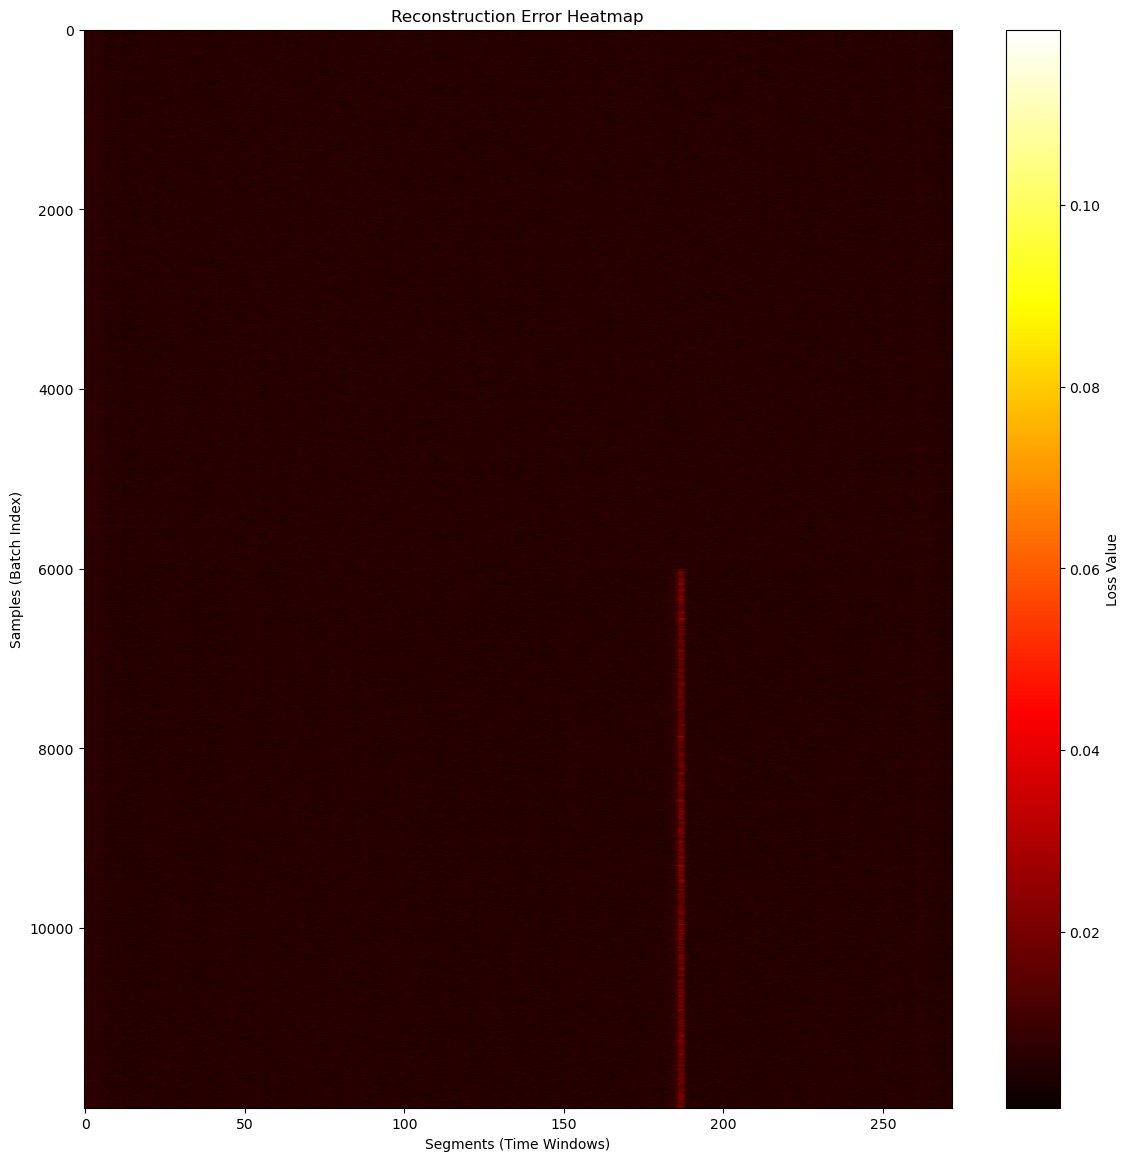

In [127]:
# Assuming 'data' is your 2D array (e.g., the [N, R] losses)
# If it's a Torch tensor, make sure to move it to CPU and convert to numpy:
# data = all_window_losses.cpu().numpy()

plt.figure(figsize=(14, 14))

# 1. Plot the heatmap
# 'aspect=auto' stretches the heatmap to fill the box (crucial for non-square matrices)
# 'interpolation=nearest' ensures pixels are crisp, not blurry
plt.imshow(grid, cmap='hot', aspect='auto')#, interpolation='nearest')

# 2. Add a colorbar (legend for values)
plt.colorbar(label='Loss Value')

# 3. Add Labels
plt.xlabel('Segments (Time Windows)')
plt.ylabel('Samples (Batch Index)')
plt.title('Reconstruction Error Heatmap')

plt.show()

In [128]:
sample = list(test_loader)[-1].reshape(-1, 100, 1).to(device)
model.eval()
with torch.no_grad():
    with torch.autocast(device_type=str(device), dtype=torch.float16): out = model(sample)
sample = sample.to('cpu')
out = out.to('cpu')

In [129]:
# full sample reconstruction (multivariate & univariate mode, have different dimensions arrangement, this is for multivariate)
# sample2 = torch.hstack([sample[0, 0, :]] + [sample[0, i, -win_stride:] for i in range(1, sample.shape[1])])
# sample2 = torch.hstack([out[0, 0, :]] + [out[0, i, -win_stride:] for i in range(1, out.shape[1])])
sample2 = torch.hstack([sample[0, 0, :]] + [sample[i, -win_stride:, 0] for i in range(1, sample.shape[0])])
out2 = torch.hstack([out[0, 0, :]] + [out[i, -win_stride:, 0] for i in range(1, out.shape[0])])

In [130]:
sample2.shape

torch.Size([16261])

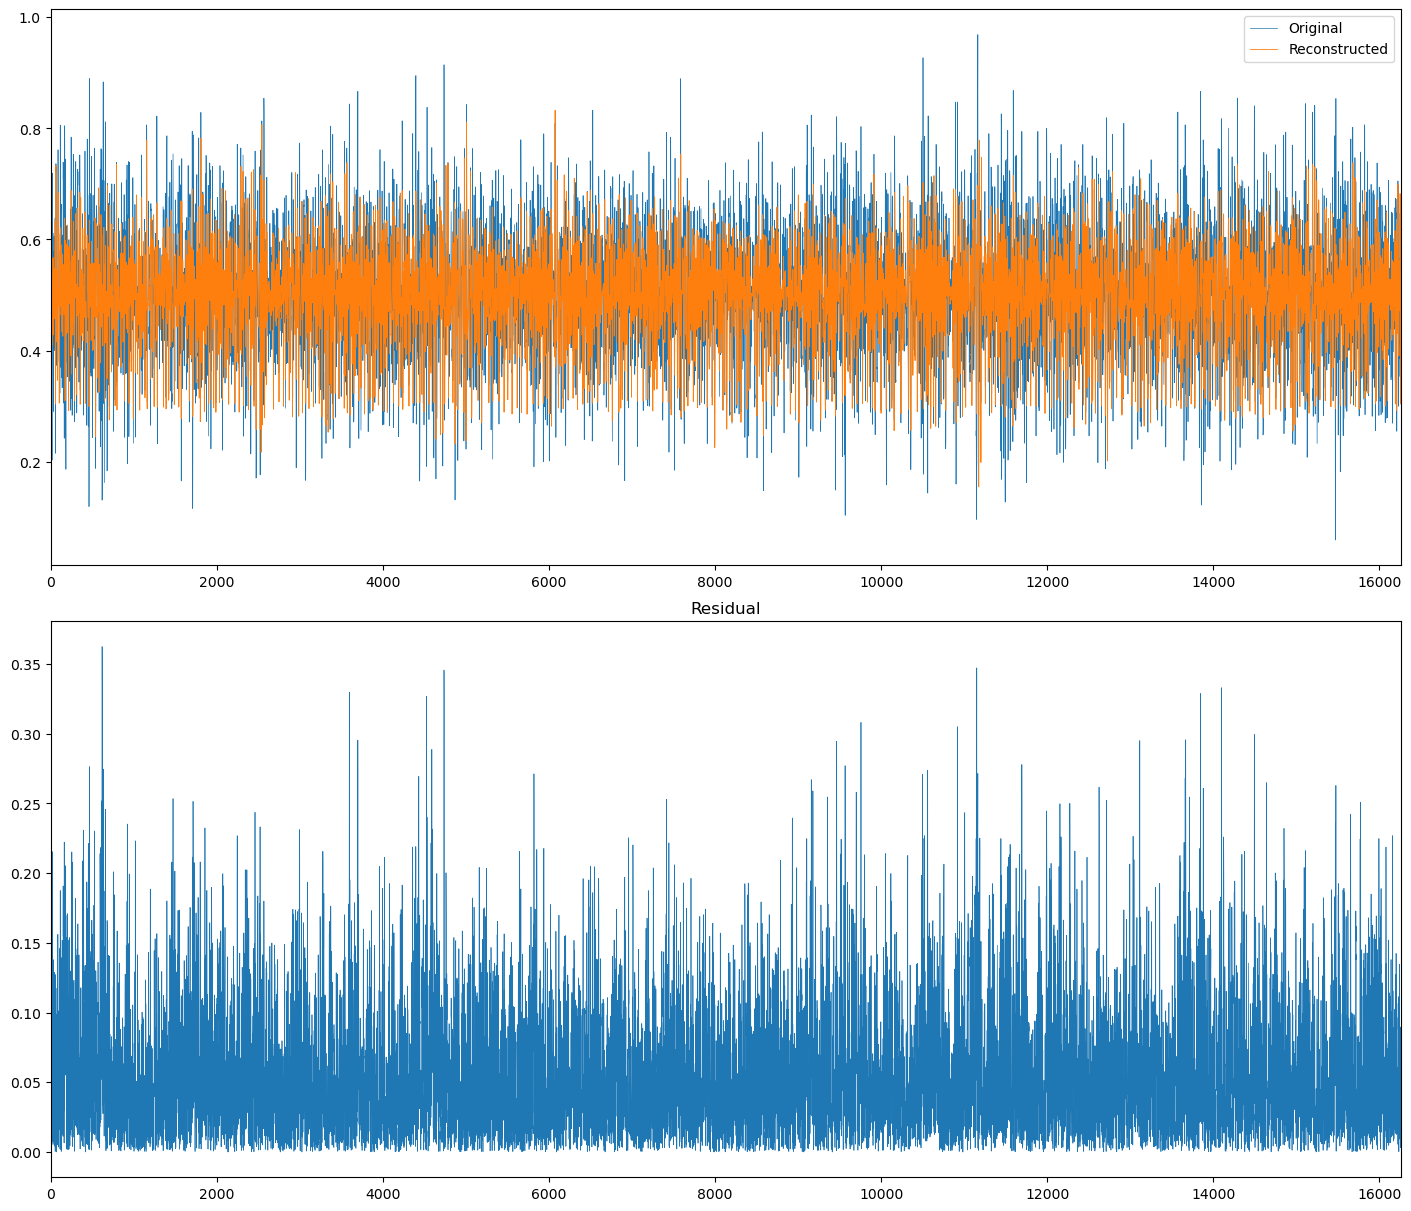

In [131]:
#Storch.max(nn.MSELoss(reduction='none')(sample2, out2))
fig, ax = plt.subplots(2, 1, figsize=(14, 12), layout='constrained')
ax[0].plot(sample2.squeeze(), lw=0.5, label='Original') 
ax[0].plot(out2.squeeze(), lw=0.6, label='Reconstructed')
ax[0].legend()

ax[1].plot((torch.abs(sample2 - out2)).squeeze(), lw=0.5)
ax[1].set_title('Residual')
for Ax in ax: Ax.set_xlim((0, len(sample2)))
plt.show()

In [94]:
### Warning: Ai copy paste below (esploration and ideas validation purpose only)


import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

value = np.mean(grid)
print("value:", value)
thresh = value + 2*grid.std()
print("tolerance::",thresh)

mask = np.abs(grid - value) > thresh

print("number of elements exceeding threshold:", np.sum(mask))
print("number on elements in noise-only samples:", np.sum(mask[:5999,:]))
print("number on elements in noise-signal samples:", np.sum(mask[5999:,:]))

plt.figure(figsize=(10, 6))

cmap = mcolors.ListedColormap(['white', 'black'])

plt.imshow(mask, cmap=cmap, aspect='auto', interpolation='nearest') # maybe we can use bigger windows not just picking some random ones

cbar = plt.colorbar(ticks=[0, 1])
cbar.ax.set_yticklabels(['Within Threshold', 'Exceeds Threshold'])

plt.xlabel('Segments ')
plt.ylabel('Samples ')
plt.title(f'Threshold Heatmap (Tol: {thresh})')
plt.show()

TypeError: mean() received an invalid combination of arguments - got (dtype=NoneType, out=NoneType, axis=NoneType, ), but expected one of:
 * (*, torch.dtype dtype = None)
 * (tuple of ints dim, bool keepdim = False, *, torch.dtype dtype = None)
 * (tuple of names dim, bool keepdim = False, *, torch.dtype dtype = None)


In [23]:
# i think a better indicator should be found.
# also we cannot count just the segments that go over the thresh bc a signal is made of many segments. wee need a better way to aggregate.

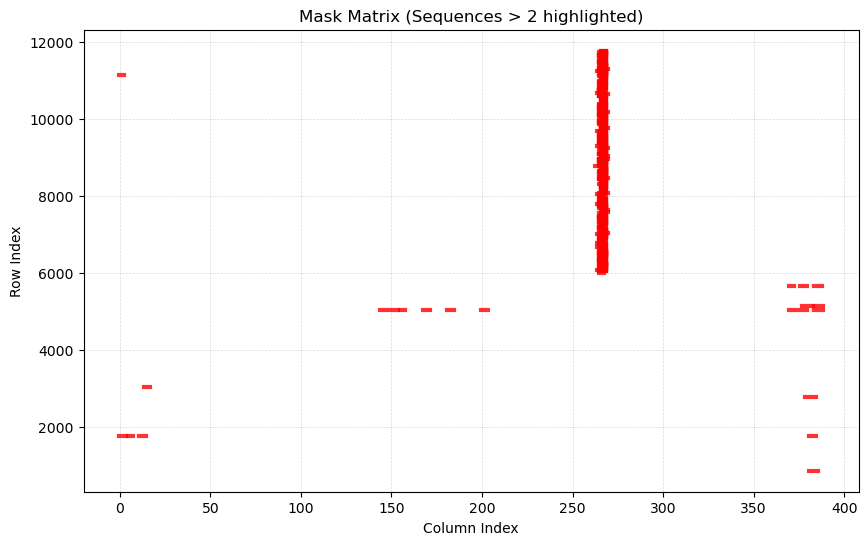

In [ ]:

###

import numpy as np
from scipy.ndimage import label
import matplotlib.pyplot as plt

def find_consecutive_trues(mask, x_threshold):
    """
    Finds rows where there are more than x_threshold consecutive True values.
    Returns the row index and the start/end column indices.
    """
    results = []
    
    for row_idx, row in enumerate(mask):
        # Label consecutive groups of True values
        # structure=[1,1,1] ensures we only look horizontally
        labeled_array, num_features = label(row)
        
        for feat in range(1, num_features + 1):
            # Find coordinates of this specific group
            indices = np.where(labeled_array == feat)[0]
            
            if len(indices) > x_threshold:
                results.append({
                    'row': row_idx,
                    'start': indices[0],
                    'end': indices[-1],
                    'count': len(indices)
                })
    return results


X = 2
matches = find_consecutive_trues(mask, X)

# --- Visualization ---
plt.figure(figsize=(10, 6))
#plt.imshow(mask, cmap='gray_r', interpolation='nearest')

# Highlight the found sequences
for m in matches:
    # Drawing a red box around the sequence
    plt.plot([m['start']-0.5, m['end']+0.5], [m['row'], m['row']], 
             color='red', linewidth=3, alpha=0.8)

plt.title(f"Mask Matrix (Sequences > {X} highlighted)")
plt.xlabel("Column Index")
plt.ylabel("Row Index")
plt.grid(visible=True, which='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.show()

# Stoopid

In [118]:
test_loss = []
for batch_data in tl.tqdm(test_loader):
        batch_data = batch_data.to(device)
        ew_loss = loss_ew(torch.zeros_like(batch_data) + .5, batch_data)
        # ew_loss = torch.hstack([ew_loss[0, 0, :]] + [ew_loss[i, -win_stride:, 0] for i in range(1, ew_loss.shape[0])])  # pointwise
        ew_loss = ew_loss.mean(dim=2)
        test_loss.append(ew_loss.squeeze(0))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12000/12000 [00:10<00:00, 1119.03it/s]


In [120]:
print(len(test_loss))
test_loss[0].shape

12000


torch.Size([272])